In [1]:
import numpy as np
import os
from imutils import paths
from keras import optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image as image_utils
from keras.applications.imagenet_utils import decode_predictions
from keras.applications.imagenet_utils import preprocess_input
import argparse
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import pandas as pd
from re import search
import shutil
import natsort
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm 
import cv2
from keras.preprocessing import image
from tensorflow.keras.models import load_model
import imutils
from distutils.version import StrictVersion
from keras.models import Sequential
#from keras.layers.convolutional import Conv2D
#from keras.layers.convolutional import MaxPooling2D
#from keras.layers.core import Activation
#from keras.layers.core import Flatten
#from keras.layers.core import Dense
from keras import backend as K
from tensorflow.keras import datasets, layers, models, losses
from IPython.display import display, Image
import os, glob
import seaborn as sns
from tensorflow.keras.callbacks import Callback,EarlyStopping
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix , classification_report 
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, roc_auc_score
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.utils import plot_model

In [2]:
aug=ImageDataGenerator(rotation_range=20,zoom_range=0.15,width_shift_range=0.2,height_shift_range=0.2,shear_range=0.15,
horizontal_flip=True,vertical_flip=False,fill_mode='nearest')

In [3]:
DATASET=r'C:\Users\Anish Kumar\Downloads\Brain tumor'
imagePaths=list(paths.list_images(DATASET))

In [4]:
imagePaths

['C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G10.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G100.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1000.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1001.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1002.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1003.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1004.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1005.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1006.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1007.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1008.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G1009.jpg',
 'C:\\Users\\Anish Kumar\\Downloads\\Brain tumor\\Glioma\\G101.jpg',
 'C:\\Users\\Anish Kumar\\D

In [5]:
Class_Names=os.listdir(r'C:\Users\Anish Kumar\Downloads\Brain tumor')
Class_Names

['Glioma', 'Healthy', 'Meningioma', 'Pituitary']

In [6]:
train_dir = r'C:\Users\Anish Kumar\Downloads\Brain tumor'
test_dir = r'C:\Users\Anish Kumar\Downloads\Brain tumor'

In [ ]:
SEED = 12
IMG_HEIGHT = 260
IMG_WIDTH = 260
BATCH_SIZE = 32
EPOCHS = 45
FINE_TUNING_EPOCHS = 20
LR = 0.001
NUM_CLASSES = 4
EARLY_STOPPING_CRITERIA=3
CLASS_LABELS  = ['Glioma', 'Healthy', 'Meningioma', 'Pituitary']

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [9]:
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(260, 260),
    batch_size=BATCH_SIZE,
    shuffle=True,
    color_mode="rgb",
    class_mode="categorical",
    subset="training",
    seed=12
)

Found 5092 images belonging to 4 classes.


In [10]:
validation_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(260, 260),
    batch_size=BATCH_SIZE,
    shuffle=False,
    color_mode="rgb",
    class_mode="categorical",
    subset="validation",
    seed=12
)

Found 1273 images belonging to 4 classes.


In [11]:
test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(260, 260),
    batch_size=BATCH_SIZE,
    shuffle=False,
    color_mode="rgb",
    class_mode="categorical"
)

Found 6365 images belonging to 4 classes.


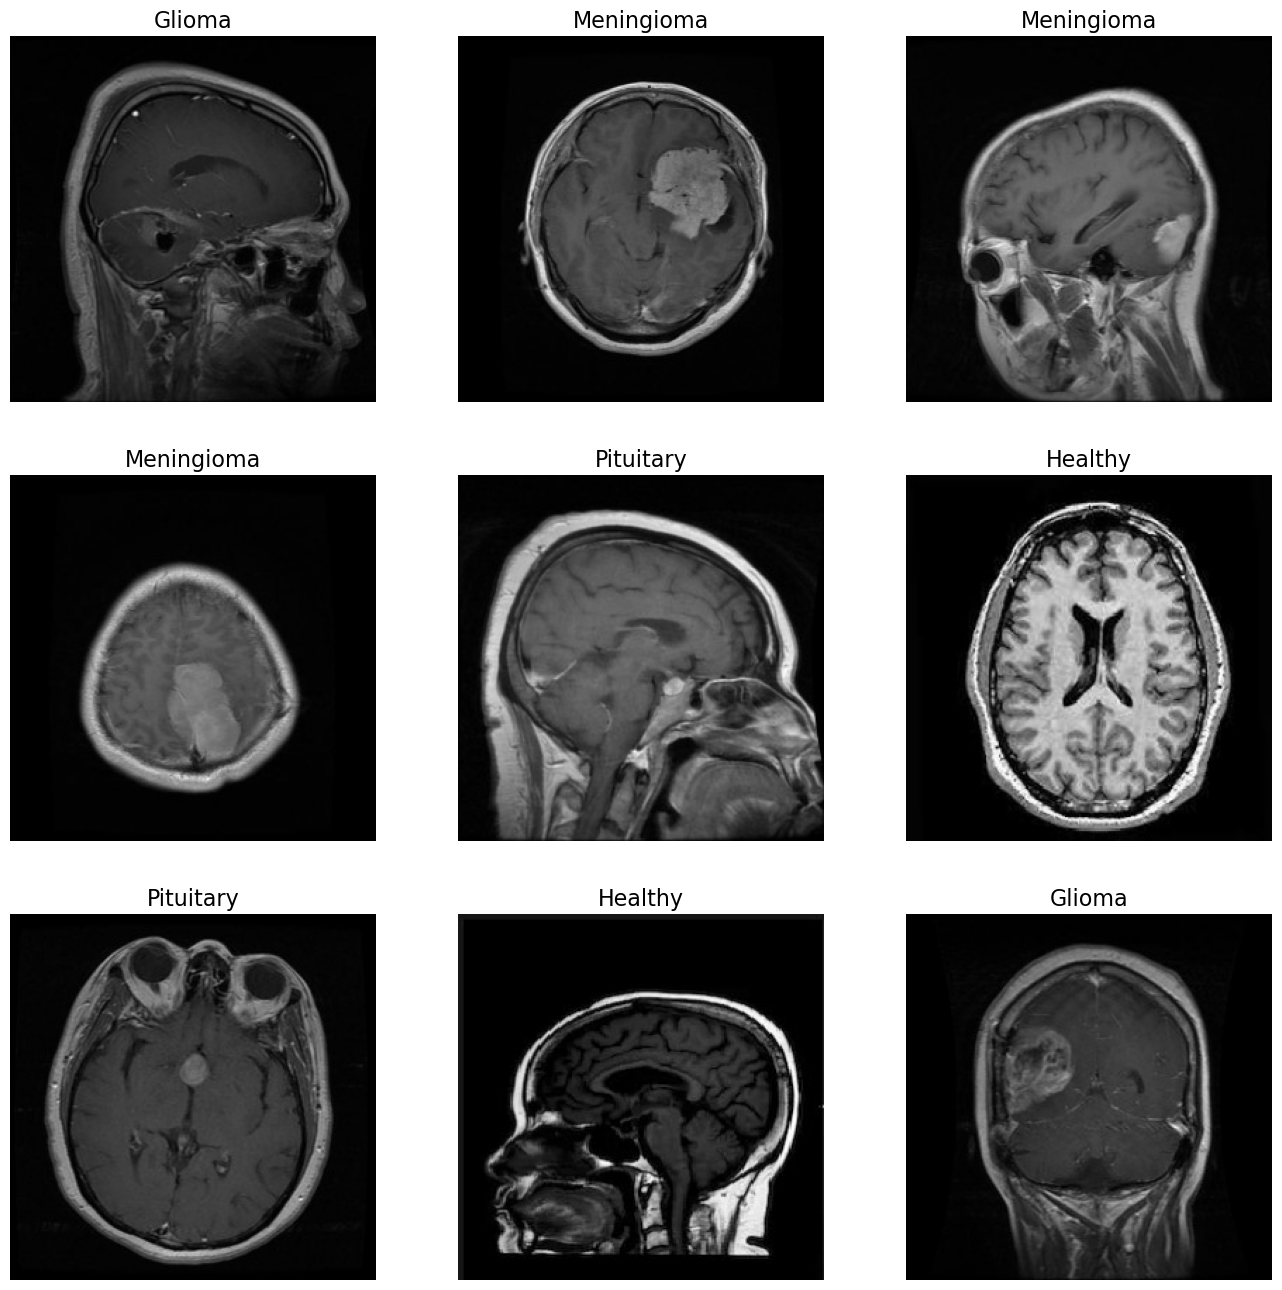

In [15]:
# Helper Functions
def display_one_image(image, title, subplot, color):
    plt.subplot(subplot)
    plt.axis('off')
    plt.imshow(image)
    plt.title(title, fontsize=16)
    
def display_nine_images(images, titles, title_colors=None):
    subplot = 331
    plt.figure(figsize=(13,13))
    for i in range(9):
        color = 'black' if title_colors is None else title_colors[i]
        display_one_image(images[i], titles[i], 331+i, color)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.2, hspace=0.2)
    plt.show()

def image_title(label, prediction):
  # Both prediction (probabilities) and label (one-hot) are arrays with one item per class.
    class_idx = np.argmax(label, axis=-1)
    prediction_idx = np.argmax(prediction, axis=-1)
    if class_idx == prediction_idx:
        return f'{CLASS_LABELS[prediction_idx]} [correct]', 'black'
    else:
        return f'{CLASS_LABELS[prediction_idx]} [incorrect, should be {CLASS_LABELS[class_idx]}]', 'red'

def get_titles(images, labels, model):
    predictions = model.predict(images)
    titles, colors = [], []
    for label, prediction in zip(classes, predictions):
        title, color = image_title(label, prediction)
        titles.append(title)
        colors.append(color)
    return titles, colors

img_datagen = ImageDataGenerator(rescale = 1./255)
img_generator = img_datagen.flow_from_directory(directory = train_dir,
                                                    target_size = (260,260),
                                                    batch_size = BATCH_SIZE,
                                                    shuffle  = True , 
                                                    color_mode = "rgb",
                                                    class_mode = "categorical",
                                                    subset = "training",
                                                    seed = 12
                                                   )

clear_output()

images, classes = next(img_generator)
class_idxs = np.argmax(classes, axis=-1) 
labels = [CLASS_LABELS[idx] for idx in class_idxs]
display_nine_images(images, labels)

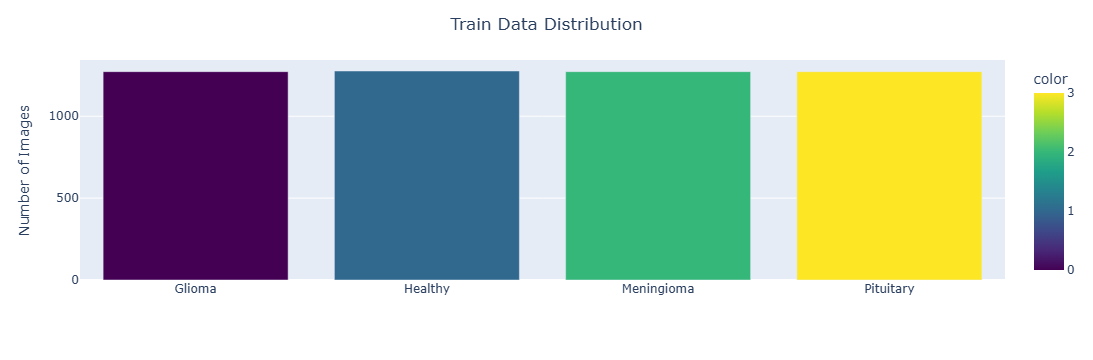

In [16]:
fig = px.bar(x = CLASS_LABELS,
             y = [list(train_generator.classes).count(i) for i in np.unique(train_generator.classes)] , 
             color = np.unique(train_generator.classes) ,
             color_continuous_scale="Viridis") 
fig.update_xaxes(title="")
fig.update_yaxes(title = "Number of Images")
fig.update_layout(showlegend = True,
    title = {
        'text': 'Train Data Distribution ',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})
fig.show()

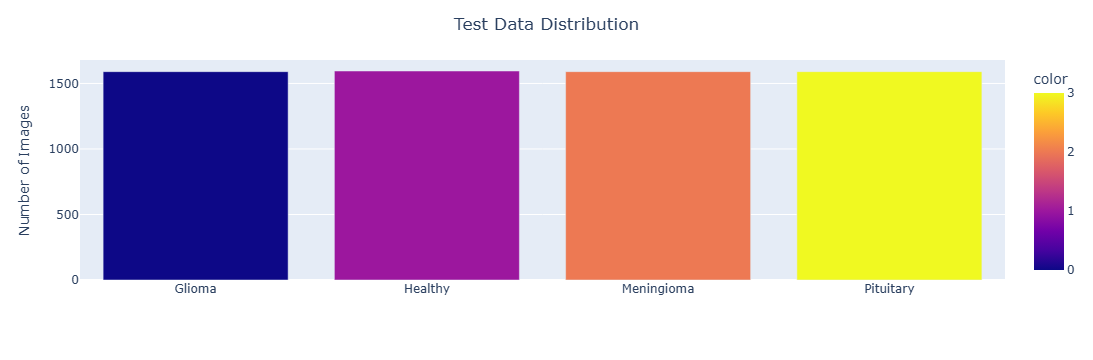

In [17]:
fig = px.bar(x = CLASS_LABELS,
             y = [list(test_generator.classes).count(i) for i in np.unique(test_generator.classes)] , 
             color = np.unique(test_generator.classes) ,
             color_continuous_scale="plasma") 
fig.update_xaxes(title="")
fig.update_yaxes(title = "Number of Images")
fig.update_layout(showlegend = True,
    title = {
        'text': 'Test Data Distribution ',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})
fig.show()

In [18]:
Original_Model= EfficientNetB2(input_shape=(260,260,3),include_top=False, weights='imagenet')
Original_Model.summary()

Model: "efficientnetb2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 260, 260,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 260, 260,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 260, 260,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 7,768,569 (29.63 MB)

 Trainable params: 7,700,994 (29.38 MB)

 Non-trainable params: 67,575 (263.97 KB)

In [19]:
Original_Model.trainable = False

In [20]:
headModel = Original_Model.output

headModel = tf.keras.layers.GlobalAveragePooling2D()(headModel)
headModel = tf.keras.layers.BatchNormalization()(headModel)

headModel = tf.keras.layers.Dense(256, activation='relu')(headModel)
headModel = tf.keras.layers.Dropout(0.4)(headModel)

NewModel = tf.keras.layers.Dense(4, activation='softmax')(headModel)

model = tf.keras.models.Model(
    inputs=Original_Model.input,
    outputs=NewModel
)

In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 260, 260,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 260, 260,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 260, 260,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 8,135,933 (31.04 MB)

 Trainable params: 364,548 (1.39 MB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
earlyStoppingCallback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_CRITERIA,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[earlyStoppingCallback],
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)
 
history = pd.DataFrame(history.history)

Epoch 1/45
159/159 ━━━━━━━━━━━━━━━━━━━━ 888s 5s/step - accuracy: 0.6621 - loss: 0.8626 - val_accuracy: 0.8061 - val_loss: 0.5845
Epoch 2/45
159/159 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.6875 - loss: 0.7078 - val_accuracy: 0.8285 - val_loss: 0.5702
Epoch 3/45
159/159 ━━━━━━━━━━━━━━━━━━━━ 959s 6s/step - accuracy: 0.8002 - loss: 0.5077 - val_accuracy: 0.8702 - val_loss: 0.3663
Epoch 4/45
159/159 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9062 - loss: 0.4089 - val_accuracy: 0.8622 - val_loss: 0.3745
Epoch 5/45
159/159 ━━━━━━━━━━━━━━━━━━━━ 853s 5s/step - accuracy: 0.8247 - loss: 0.4429 - val_accuracy: 0.8830 - val_loss: 0.3037
Epoch 6/45
159/159 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9062 - loss: 0.2007 - val_accuracy: 0.8774 - val_loss: 0.3184
Epoch 7/45
159/159 ━━━━━━━━━━━━━━━━━━━━ 1447s 9s/step - accuracy: 0.8626 - loss: 0.3589 - val_accuracy: 0.8910 - val_loss: 0.2702
Epoch 8/45
159/159 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9375 - loss: 0.2665 - val_acc

In [24]:
for layer in Original_Model.layers[-20:]:
    layer.trainable = True

In [25]:
# ------------------------------------
# Compile with lower learning rate
# ------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------
# Fine-tuning training
# ------------------------------------
history_fine = model.fit(
    train_generator,
    epochs=FINE_TUNING_EPOCHS,
    validation_data=validation_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

# ------------------------------------
# Merge history correctly (pandas-safe)
# ------------------------------------
history = pd.concat(
    [history, pd.DataFrame(history_fine.history)],
    ignore_index=True
)

Epoch 1/48
159/159 ━━━━━━━━━━━━━━━━━━━━ 1084s 6s/step - accuracy: 0.9042 - loss: 0.2489 - val_accuracy: 0.9183 - val_loss: 0.2005
Epoch 2/48
159/159 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9375 - loss: 0.1591 - val_accuracy: 0.9287 - val_loss: 0.1967
Epoch 3/48
159/159 ━━━━━━━━━━━━━━━━━━━━ 997s 6s/step - accuracy: 0.9111 - loss: 0.2325 - val_accuracy: 0.9215 - val_loss: 0.1876
Epoch 4/48
159/159 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9375 - loss: 0.1299 - val_accuracy: 0.9199 - val_loss: 0.1966
Epoch 5/48
159/159 ━━━━━━━━━━━━━━━━━━━━ 966s 6s/step - accuracy: 0.9190 - loss: 0.2190 - val_accuracy: 0.9215 - val_loss: 0.2026
Epoch 6/48
159/159 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.9375 - loss: 0.1153 - val_accuracy: 0.9199 - val_loss: 0.2057
Epoch 7/48
159/159 ━━━━━━━━━━━━━━━━━━━━ 1070s 7s/step - accuracy: 0.9269 - loss: 0.1976 - val_accuracy: 0.9207 - val_loss: 0.1977
Epoch 8/48
159/159 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9062 - loss: 0.2527 - val_ac

In [31]:
import os

save_dir = r"C:\Users\Anish Kumar\Downloads\Brain tumor\model"
os.makedirs(save_dir, exist_ok=True)

model.save(
    os.path.join(save_dir, "EfficientNetB2.keras")
)

In [32]:
from tensorflow.keras.models import load_model

model = load_model(
    r'C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB2.keras'
)

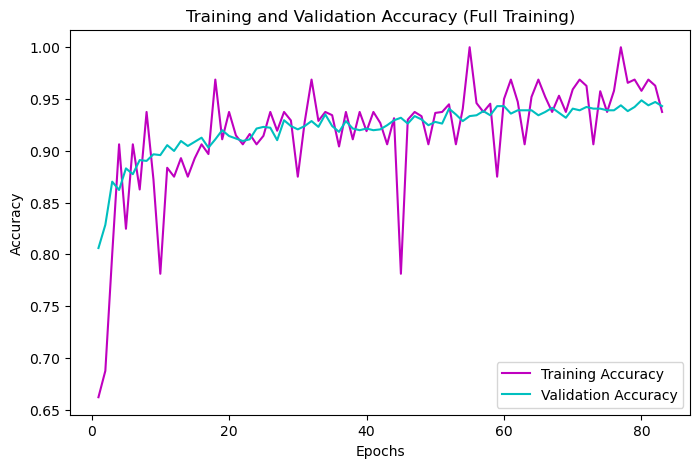

In [33]:
acc_train = history['accuracy']
acc_val   = history['val_accuracy']

epochs = range(1, len(acc_train) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, acc_train, 'm', label='Training Accuracy')
plt.plot(epochs, acc_val, 'c', label='Validation Accuracy')
plt.title("Training and Validation Accuracy (Full Training)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

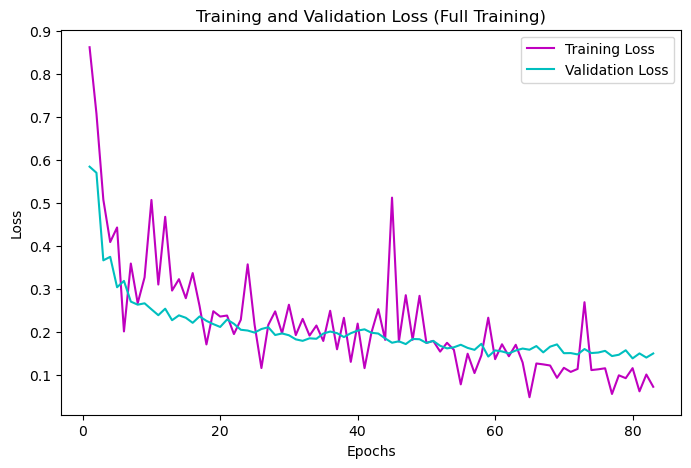

In [34]:
loss_train = history['loss']
loss_val   = history['val_loss']

epochs = range(1, len(loss_train) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, loss_train, 'm', label='Training Loss')
plt.plot(epochs, loss_val, 'c', label='Validation Loss')
plt.title("Training and Validation Loss (Full Training)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [35]:
model.evaluate(test_generator)

preds = model.predict(test_generator)
y_preds = np.argmax(preds, axis=1)

y_test = np.array(test_generator.labels)

199/199 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - accuracy: 0.9849 - loss: 0.0478
199/199 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step


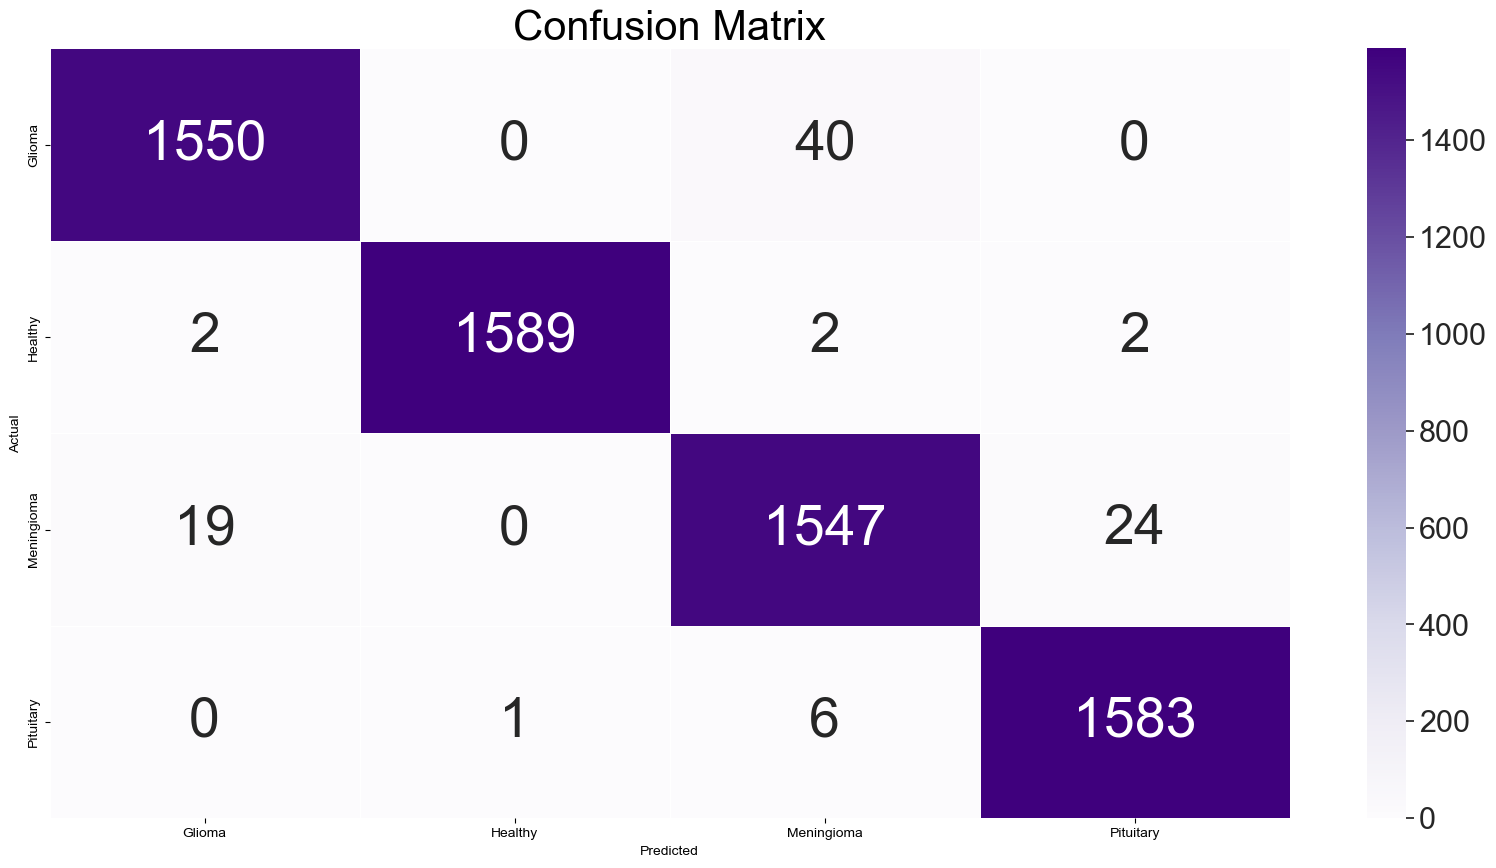

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cm_data = confusion_matrix(y_test, y_preds)

cm = pd.DataFrame(
    cm_data,
    index=CLASS_LABELS,
    columns=CLASS_LABELS
)

cm.index.name = 'Actual'
cm.columns.name = 'Predicted'

plt.figure(figsize=(20, 10))
plt.title('Confusion Matrix', fontsize=30)

sns.set(font_scale=2)
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Purples',
    linewidths=0.5,
    cbar=True,
    annot_kws={"size": 40},
    cbar_kws={"orientation": "vertical"}
)

plt.show()

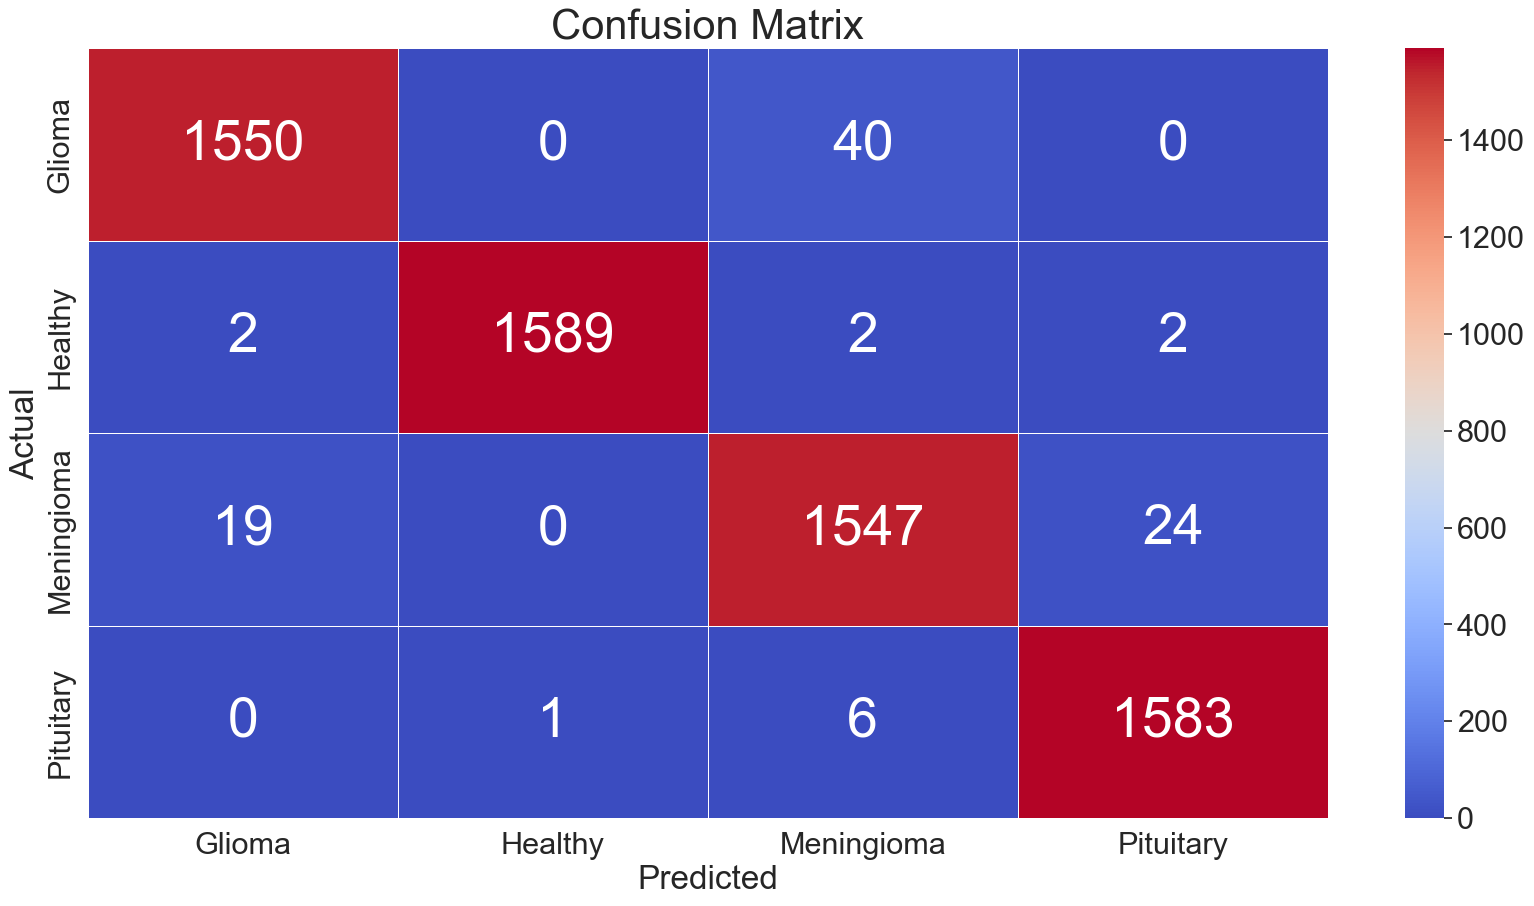

In [37]:
cm_data = confusion_matrix(y_test , y_preds)

cm = pd.DataFrame(
    cm_data,
    columns=CLASS_LABELS,
    index=CLASS_LABELS
)

cm.index.name = 'Actual'
cm.columns.name = 'Predicted'

plt.figure(figsize=(20,10))
plt.title('Confusion Matrix', fontsize=30)

sns.set(font_scale=2)
ax = sns.heatmap(
    cm,
    cbar=True,
    cmap="coolwarm",
    annot=True,
    linewidth=0.5,
    annot_kws={"size": 40},
    cbar_kws={"orientation":"vertical"},
    fmt='g'
)

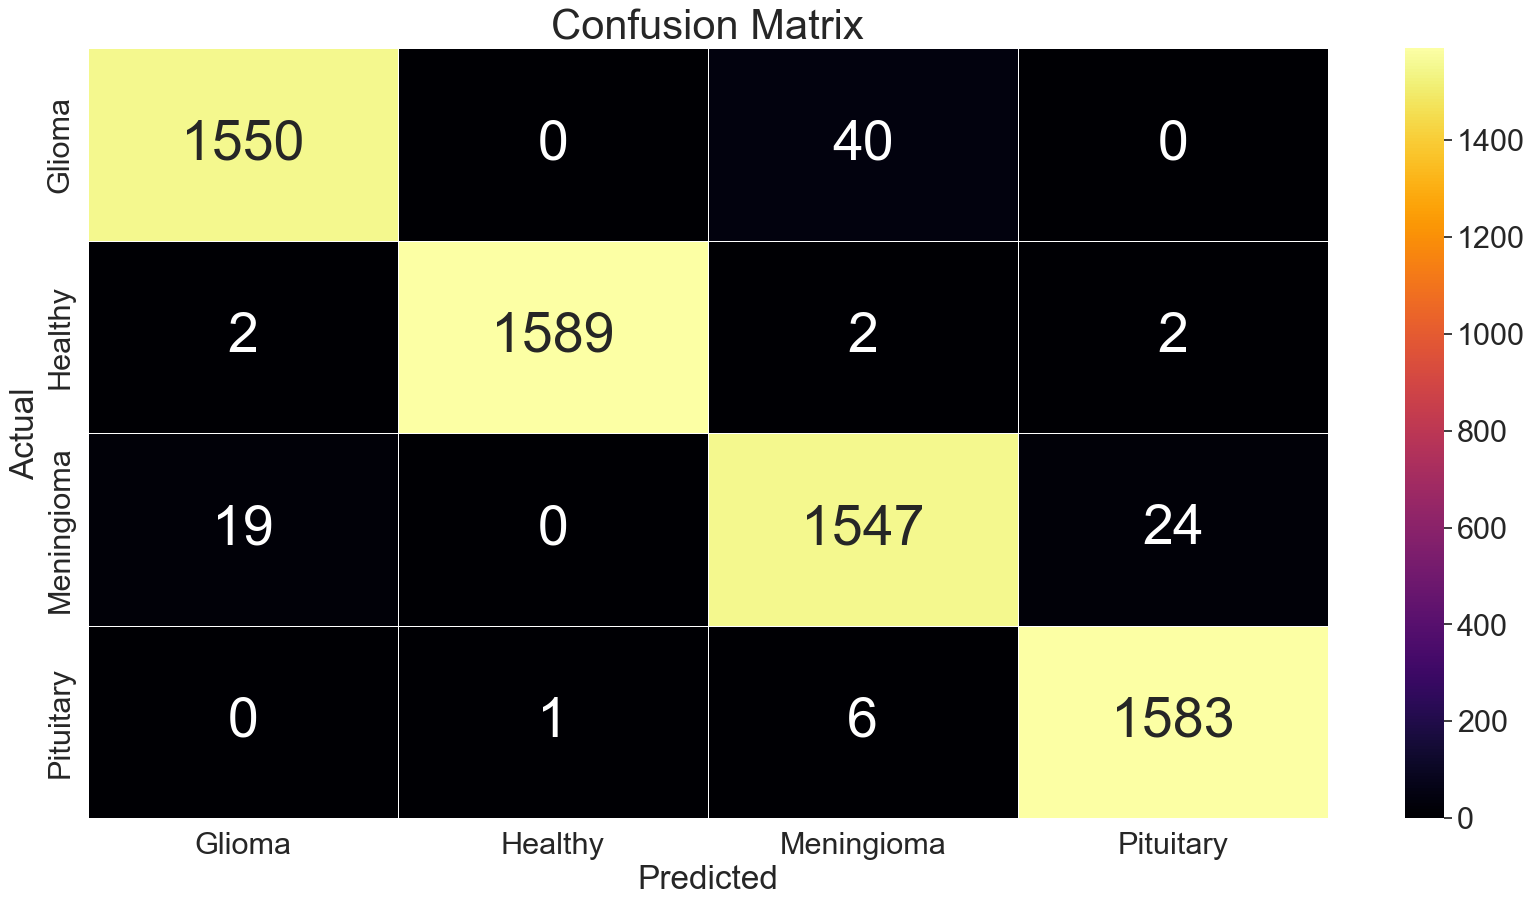

In [38]:
cm_data = confusion_matrix(y_test , y_preds)
cm = pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
cm.index.name = 'Actual'
cm.columns.name = 'Predicted'
plt.figure(figsize = (20,10))
plt.title('Confusion Matrix', fontsize = 30)
sns.set(font_scale=2)
ax = sns.heatmap(cm, cbar=True, cmap="inferno", annot=True, linewidth=0.5, annot_kws={"size": 40}, cbar_kws={"orientation":"vertical"}, fmt='g')

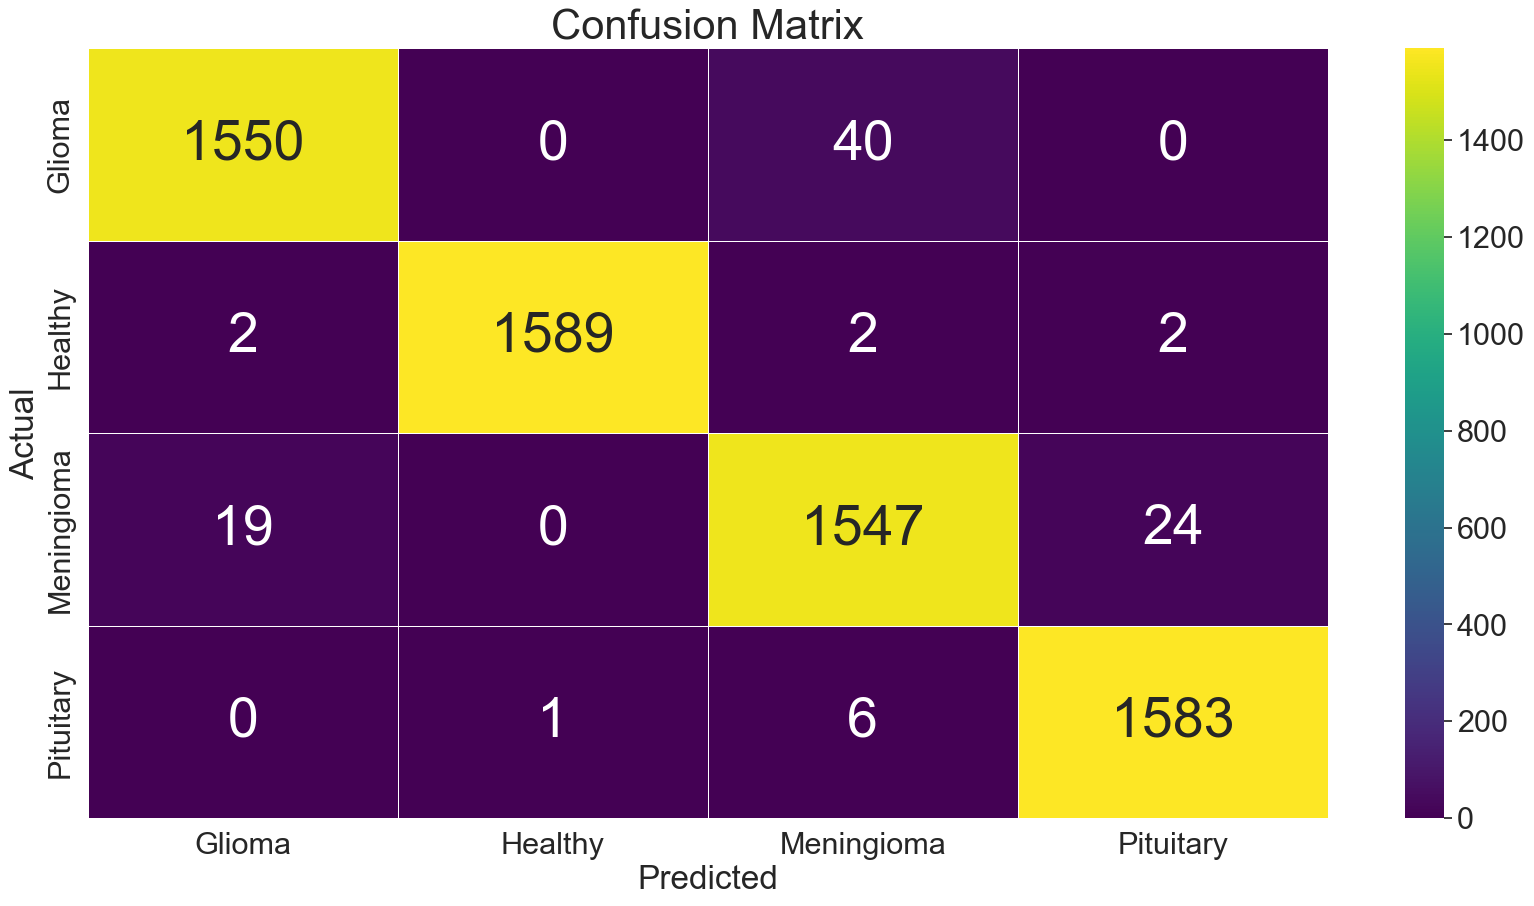

In [39]:
cm_data = confusion_matrix(y_test , y_preds)
cm = pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
cm.index.name = 'Actual'
cm.columns.name = 'Predicted'
plt.figure(figsize = (20,10))
plt.title('Confusion Matrix', fontsize = 30)
sns.set(font_scale=2)
ax = sns.heatmap(cm, cbar=True, cmap="viridis", annot=True, linewidth=0.5, annot_kws={"size": 40}, cbar_kws={"orientation":"vertical"}, fmt='g')

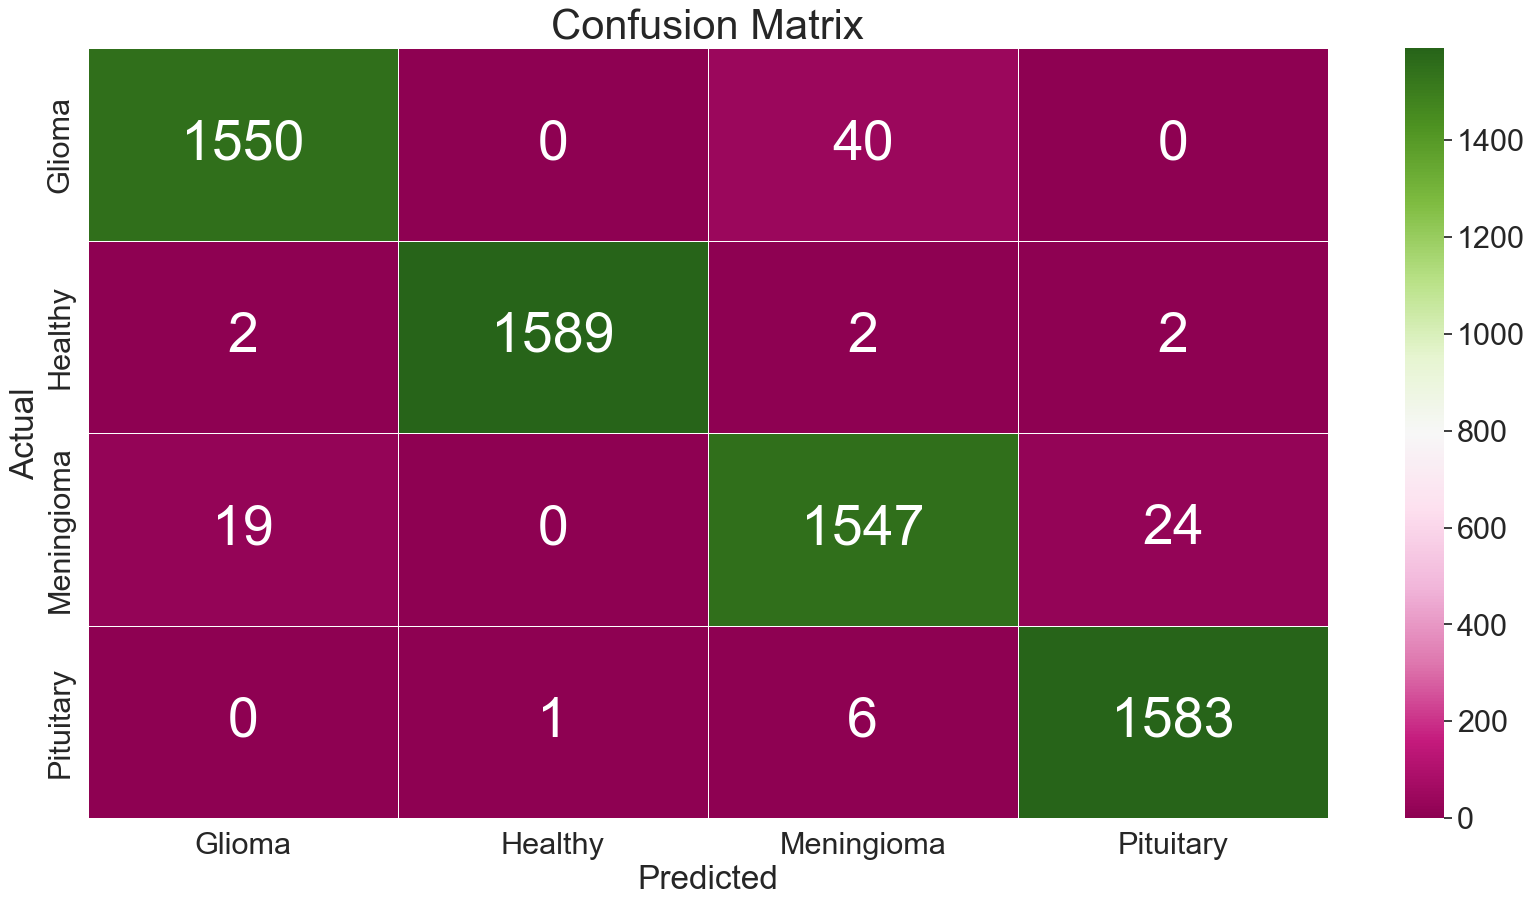

In [40]:
cm_data = confusion_matrix(y_test , y_preds)

cm = pd.DataFrame(
    cm_data,
    columns=CLASS_LABELS,
    index=CLASS_LABELS
)

cm.index.name = 'Actual'
cm.columns.name = 'Predicted'

plt.figure(figsize=(20,10))
plt.title('Confusion Matrix', fontsize=30)

sns.set(font_scale=2)
ax = sns.heatmap(
    cm,
    cbar=True,
    cmap="PiYG",
    annot=True,
    linewidth=0.5,
    annot_kws={"size": 40},
    cbar_kws={"orientation":"vertical"},
    fmt='g'
)
plt.show()

In [41]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1590
           1       1.00      1.00      1.00      1595
           2       0.97      0.97      0.97      1590
           3       0.98      1.00      0.99      1590

    accuracy                           0.98      6365
   macro avg       0.98      0.98      0.98      6365
weighted avg       0.98      0.98      0.98      6365



ROC AUC score: 0.9995405039547786


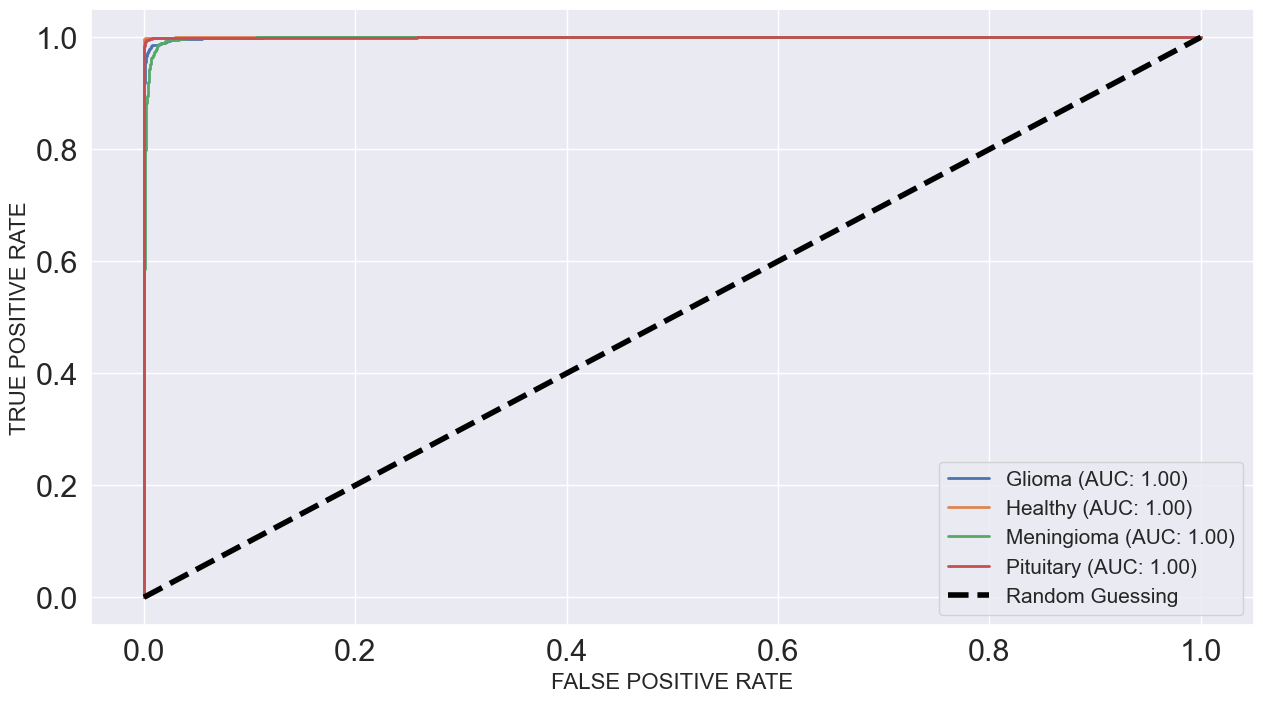

In [42]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, roc_auc_score

fig, c_ax = plt.subplots(1, 1, figsize=(15, 8))

def multiclass_roc_auc_score(y_test, y_pred, average="macro"):
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    for idx, c_label in enumerate(CLASS_LABELS):
        fpr, tpr, _ = roc_curve(
            y_test_bin[:, idx].astype(int),
            y_pred[:, idx]
        )
        c_ax.plot(
            fpr,
            tpr,
            lw=2,
            label=f'{c_label} (AUC: {auc(fpr, tpr):0.2f})'
        )

    # Random guessing baseline
    c_ax.plot(
        [0, 1],
        [0, 1],
        'black',
        linestyle='dashed',
        lw=4,
        label='Random Guessing'
    )

    return roc_auc_score(y_test_bin, y_pred, average=average)

print(
    'ROC AUC score:',
    multiclass_roc_auc_score(y_test, preds, average="micro")
)

plt.xlabel('FALSE POSITIVE RATE', fontsize=16)
plt.ylabel('TRUE POSITIVE RATE', fontsize=16)
plt.legend(fontsize=15)
plt.show()

In [43]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras.utils import to_categorical

roc_auc = roc_auc_score(
    to_categorical(y_test),
    preds,
    average="macro",
    multi_class="ovr"
)

print("ROC-AUC (Macro, OvR) =", roc_auc)

ROC-AUC (Macro, OvR) = 0.9994103346669473


In [44]:
roc_auc = roc_auc_score(
    to_categorical(y_test),
    preds,
    average="micro",
    multi_class="ovr"
)

print("ROC-AUC (Micro, OvR) =", roc_auc)

ROC-AUC (Micro, OvR) = 0.9995405039547786


In [45]:
model.save(r'C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientnetB2.h5')